In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 ## Data Loading

In [6]:
#loading the dataset

df = pd.read_csv("../data/HealthConnect_Appointment_Data.csv")

df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## Data Inspection + Cleaning

In [7]:
df.shape

(5000, 18)

In [8]:
df.columns

Index(['appointment_id', 'patient_id', 'gender', 'age', 'age_group',
       'appointment_type', 'booking_date', 'appointment_date',
       'appointment_day', 'appointment_time', 'booking_lead_days',
       'previous_appointments', 'previous_no_shows', 'reminder_sent',
       'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes',
       'appointment_outcome'],
      dtype='object')

In [16]:
#to see the data types of our columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

Booking and appointment date columns should be of the date type, not objects(strings).

In [10]:
df.describe(include='object')

,appointment_id,patient_id,gender,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,reminder_sent,reminder_channel,appointment_outcome
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,3634,5000
unique,5000,1696,3,6,4,593,545,7,3,2,3,3
top,HC-00001,P-1399,Female,65+,General Consultation,8/24/2025,3/14/2026,Wednesday,Morning,Yes,SMS,No-Show
freq,1,9,2488,1241,2086,20,18,737,2227,3634,2000,2423


In [13]:
#makimg a table to see how many missing values we have in each column
missing = df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round((missing/len(df))*100,2)
})

missing



,Missing Values,Percentage
appointment_id,0,0.00
patient_id,0,0.00
gender,0,0.00
age,0,0.00
age_group,0,0.00
appointment_type,0,0.00
booking_date,0,0.00
appointment_date,0,0.00
appointment_day,0,0.00
appointment_time,0,0.00


In [27]:
pd.crosstab(df['reminder_sent'], df['reminder_channel'])

reminder_channel,Email,SMS,WhatsApp
reminder_sent,,,
Yes,533,2000,1101


About 27% of the data is missing values in teh reminder channel column. And just under 2% of thhe data is missing valuees for waiting time and distance to clinic.  As for the wait time and distance to clinic, i think we can continue because it is less than 2% of the data thats missing this info. 

In [26]:
df[['reminder_sent', 'reminder_channel']].head()

,reminder_sent,reminder_channel
0,Yes,WhatsApp
1,Yes,SMS
2,Yes,SMS
3,Yes,SMS
4,Yes,Email


In [14]:
#checking for duplicates

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [17]:
#changing booking date and appintment date datatypes
df['booking_date'] = pd.to_datetime(df['booking_date'])

df['appointment_date'] = pd.to_datetime(df['appointment_date'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   appointment_id         5000 non-null   object        
 1   patient_id             5000 non-null   object        
 2   gender                 5000 non-null   object        
 3   age                    5000 non-null   int64         
 4   age_group              5000 non-null   object        
 5   appointment_type       5000 non-null   object        
 6   booking_date           5000 non-null   datetime64[ns]
 7   appointment_date       5000 non-null   datetime64[ns]
 8   appointment_day        5000 non-null   object        
 9   appointment_time       5000 non-null   object        
 10  booking_lead_days      5000 non-null   int64         
 11  previous_appointments  5000 non-null   int64         
 12  previous_no_shows      5000 non-null   int64         
 13  rem

## Exploratory Data Analysis

#### Appointment Outcome Distribution

In [19]:
#Seeing the number of attended, unattended, and cancelled appointments

df['appointment_outcome'].value_counts()


appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

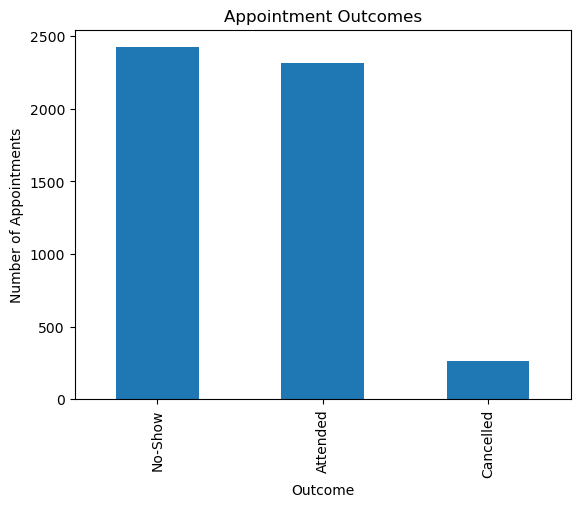

In [20]:
df['appointment_outcome'].value_counts().plot(kind='bar')

plt.title("Appointment Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Appointments")

plt.show()

Appointment attendance and no-shows occur in similar proportions, with no-shows slightly exceeding attended appointments. Approximately 5% of appointments were cancelled. This suggests that appointment non-attendance is a significant operational issue for HealthConnect Clinic and supports the project's objective of understanding factors associated with missed appointments.

#### Gender Distribution

In [21]:
df['gender'].value_counts()

gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

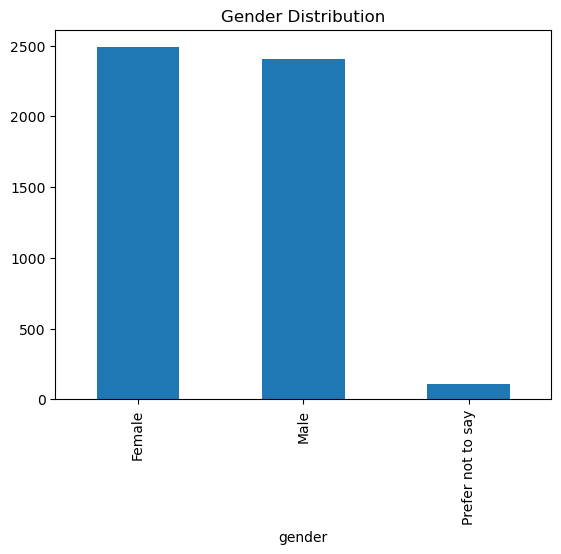

In [22]:
df['gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")

plt.show()

The male and female genders are almost equally distributed. Indicating that the dataset is well balanced with respect to gender.

#### Age Distribution

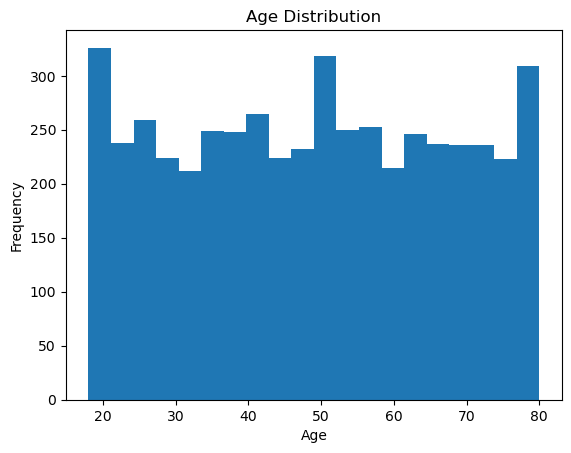

In [23]:
plt.hist(df['age'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()
        

The age distribution shows several peaks, particularly among patients in their twenties, around age fifty, and in the late seventies to early eighties. Further analysis will determine whether these age groups exhibit different appointment attendance patterns.

#### Appointment Type

In [24]:
df['appointment_type'].value_counts()

appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

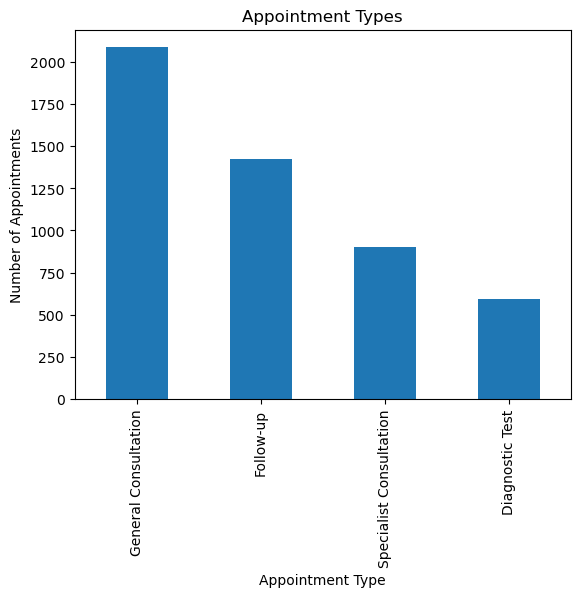

In [25]:
df['appointment_type'].value_counts().plot(kind='bar')

plt.title("Appointment Types")
plt.xlabel("Appointment Type")
plt.ylabel("Number of Appointments")

plt.show()

The most common appointment type is General Consultation with just over 2000 appointments falling under this.
Diagnostic Tests are the least common, with fewer than 600 appointments.



#### Reminder Information

In [29]:
df['reminder_sent'].value_counts()

reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64

In [30]:
df['reminder_channel'].value_counts()

reminder_channel
SMS         2000
WhatsApp    1101
Email        533
Name: count, dtype: int64

We have 3264 reminders sent and 1366 have not been sent. 
2000 SMSs, 1101 WhatsApps and 533 E-mails all add up to 3634 so 
that means the missing values under reminder_channel 
signify the reminders that were not able to be sent.

#### Previous No-Shows

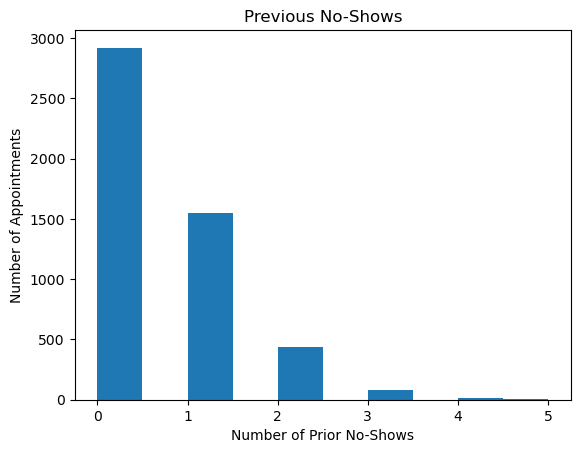

In [32]:
plt.hist(df['previous_no_shows'])

plt.title("Previous No-Shows")
plt.xlabel("Number of Prior No-Shows")
plt.ylabel("Number of Appointments")

plt.show()

In [ ]:
A great number of appointments do not have prior no-shows. 
About 1500 appointments have had 1 noo show befoore.
And the number keeps decreasing.


#### Distance to Clinic

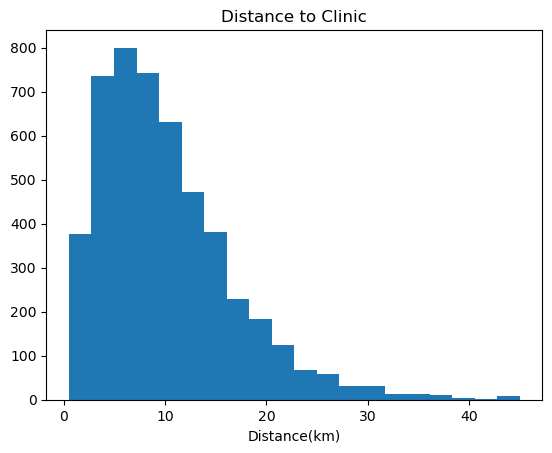

In [34]:
plt.hist(df['distance_to_clinic_km'], bins=20)

plt.title("Distance to Clinic")
plt.xlabel("Distance(km)")

plt.show()

The distance to the clinic is not evenly distributed. Approximately 800 appointments involve patients living around 10 km from the clinic, making this the most common travel distance in the dataset.

#### Waiting Time

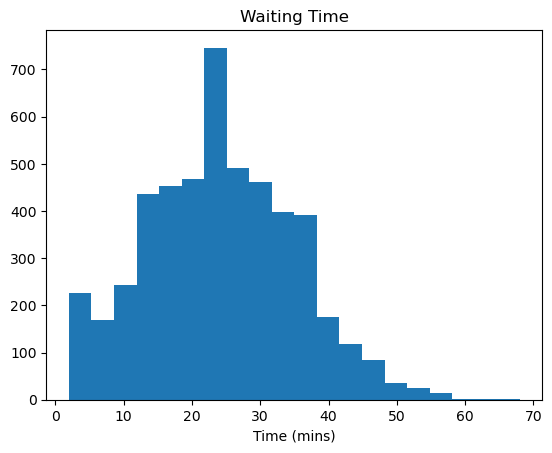

In [35]:
plt.hist(df['waiting_time_minutes'], bins=20)

plt.title("Waiting Time")
plt.xlabel("Time (mins)")

plt.show()

Waiting times are concentrated around 30 minutes, with approximately 700 appointments experiencing a waiting time of around 30 minutes. This suggests that a 30-minute wait is common at the clinic.Waiting times are concentrated around 30 minutes, with approximately 700 appointments experiencing a waiting time of around 30 minutes. This suggests that a 30-minute wait is common at the clinic.


#### Does sending of reminders affect appintment outcome? 

In [36]:
pd.crosstab(df['reminder_sent'], df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,583,81,702
Yes,1731,182,1721


#### Is there a relatioonship between appointmeent type and appointment outcome?


In [37]:
pd.crosstab(df['appointment_type'], df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,272,26,295
Follow-up,616,77,728
General Consultation,1007,106,973
Specialist Consultation,419,54,427


General Consultation has the highest number of attended appointments, cancellations, and no-shows. This is expected because it is the most common appointment type in the dataset.

In several appointment types, no-shows slightly exceed attendances, whereas General Consultation is the only appointment type where attendances are higher than no-shows.

#### Does gender affect outcome?

In [38]:
pd.crosstab(df['gender'], df['appointment_outcome'])


appointment_outcome,Attended,Cancelled,No-Show
gender,,,
Female,1153,130,1205
Male,1103,130,1171
Prefer not to say,58,3,47


There is no correlation between gender and outcome.
Though from the table we see that women are slightly more likely to not show up compared to men. 

#### Age Group vs Outcome

In [44]:
pd.crosstab(
    df['age_group'], 
    df['appointment_outcome'],
    normalize = 'index'
).mul(100).round(1)


appointment_outcome,Attended,Cancelled,No-Show
age_group,,,
18-24,45.6,4.3,50.2
25-34,45.1,4.2,50.7
35-44,45.7,6.0,48.4
45-54,46.0,5.9,48.0
55-64,45.0,4.2,50.7
65+,48.8,6.1,45.1


I think it would be easier to see these as percentages.

#### Previous No-Shows vs Outcome

In [46]:
pd.crosstab(
    df['previous_no_shows'], 
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,50.5,6.0,43.5
1,42.2,4.3,53.5
2,36.3,4.3,59.4
3,29.5,2.6,67.9
4,33.3,0.0,66.7
5,0.0,0.0,100.0


As we can see people who ohave had no shows before are more likely to be no shows again.

#### Correlation

In [41]:
numeric = df.select_dtypes(include=['number'])

numeric.corr()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
age,1.000000,-0.026700,-0.007581,0.012409,0.002476,0.005584
booking_lead_days,-0.026700,1.000000,0.004173,0.000206,-0.007494,0.009729
previous_appointments,-0.007581,0.004173,1.000000,0.458792,0.002372,-0.012881
previous_no_shows,0.012409,0.000206,0.458792,1.000000,0.009621,-0.001965
distance_to_clinic_km,0.002476,-0.007494,0.002372,0.009621,1.000000,-0.007561
waiting_time_minutes,0.005584,0.009729,-0.012881,-0.001965,-0.007561,1.000000


???? I dont understand this one.

Initial Findings

• The dataset contains 5,000 appointment records.
• A small number of missing values were identified.
• The dataset appears suitable for further analysis after basic cleaning.
• Variables such as previous no-shows, reminder status, waiting time and distance to the clinic appear likely to influence appointment attendance.
• Further analysis in Week 5 will explore these relationships in greater detail.